# pandas를 사용한 데이터 분석 
 
### 파일 읽기
 
대부분의 데이터셋은 열과 열을 구분하기 위한 구분자로 특정한 문자를 사용한다. 구분자는 보통 콤마 ','를 많이 쓰는데, 콤마를 구분자로 사용한 파일을 특별히 'CSV(comma-separated values) 파일'이라고 부른다.
  
 ** df = pd.read_csv("data/lending-club-loan-data/loan.csv", sep=",")** 

 
### Lending Club Loan dataset 분석하기
 
** Lending Club Loan dataset의 주요 컬럼 요약** 
 
 **• loan_amnt: 대출자의 대출 총액**
 
 • funded_amnt: 해당 대출을 위해 모금된 총액
 
 • issue_d: 대출을 위한 기금이 모금된 월
 
 **• loan_status: 대출의 현재 상태**
 
 • title: 대출자에 의해 제공된 대출 항목
 
 • purpose: 대출자에 의해 제공된 대출 목적
 
 • emp_length: 대출자의 재직 기간
 
 **• grade: LC assigned loan grade**
 
 **• int_rate: 대출 이자율**
 
 **• term: 대출 상품의 기간 (36-month vs. 60-month)**
 
 **• int_status : 대출 상태  (Fully Paid', 'Charged Off', 'Current)
  
* 불량 상태(bad status): "Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "In Grace Period", "Default Receiver", "Late (16-30 days)", "Late (31-120 days)"  
 
** LC loan grade 참고: https://www.lendingclub.com/public/rates-and-fees.action  **

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
df = pd.read_csv('data/loan.csv', sep = ',')

C:\Users\admin\AppData\Local\Temp\ipykernel_14600\2519303798.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/loan.csv', sep = ',')


In [55]:
df.head(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [57]:
df.shape

(2260701, 151)

In [58]:
# 필요한 컬럼만 가져오기
df2 = df[['loan_amnt', 'loan_status', 'grade', 'int_rate', 'term']]

In [59]:
df2.head(10)

,loan_amnt,loan_status,grade,int_rate,term
0,3600.0,Fully Paid,C,13.99,36 months
1,24700.0,Fully Paid,C,11.99,36 months
2,20000.0,Fully Paid,B,10.78,60 months
3,35000.0,Current,C,14.85,60 months
4,10400.0,Fully Paid,F,22.45,60 months
5,11950.0,Fully Paid,C,13.44,36 months
6,20000.0,Fully Paid,B,9.17,36 months
7,20000.0,Fully Paid,B,8.49,36 months
8,10000.0,Fully Paid,A,6.49,36 months
9,8000.0,Fully Paid,B,11.48,36 months


In [60]:
df2.tail()

,loan_amnt,loan_status,grade,int_rate,term
2260696,40000.0,Current,B,10.49,60 months
2260697,24000.0,Charged Off,C,14.49,60 months
2260698,14000.0,Current,C,14.49,60 months
2260699,NaN,NaN,NaN,NaN,NaN
2260700,NaN,NaN,NaN,NaN,NaN


In [61]:
df2['loan_status'].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default', nan,
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [62]:
df2['grade'].unique()

array(['C', 'B', 'F', 'A', 'E', 'D', 'G', nan], dtype=object)

In [63]:
df2['term'].unique()

array([' 36 months', ' 60 months', nan], dtype=object)

In [64]:
df2.shape

(2260701, 5)

In [65]:
#nan 제거하기   * how = 'any' 는 nan이 있는 행은 모두 삭제 / how ='all' 은 행 전체에 nan이 있는 경우에만 행 삭제. 그렇지 않으면 삭제 안함
df2 = df2.dropna(how = 'any')

In [66]:
df2.shape

(2260668, 5)

# 30개월 / 60개월 두 가지 대출 상품을 운영
# 문제) '36개월 대출'과 '60개월 대출'의 대출 총액 파악

In [68]:
# 결과를 저장할 딕녀너리 생성
term_to_loan_amnt_dict = {}
# term 컬럼의 고유값 추출
uniq_terms = df2['term'].unique()
uniq_terms

array([' 36 months', ' 60 months'], dtype=object)

In [69]:
# 각 대출기간에 대해 반복 계산
# 대출기간에 해당하는 행들의 loan_amnt(대출금액) 컬럼 합계 계산
for term in uniq_terms:
    loan_amnt_sum = df2.loc[df2['term'] == term, 'loan_amnt'].sum()
    term_to_loan_amnt_dict[term] = loan_amnt_sum


In [70]:
term_to_loan_amnt_dict

{' 36 months': np.float64(20517162875.0),
 ' 60 months': np.float64(13498953050.0)}

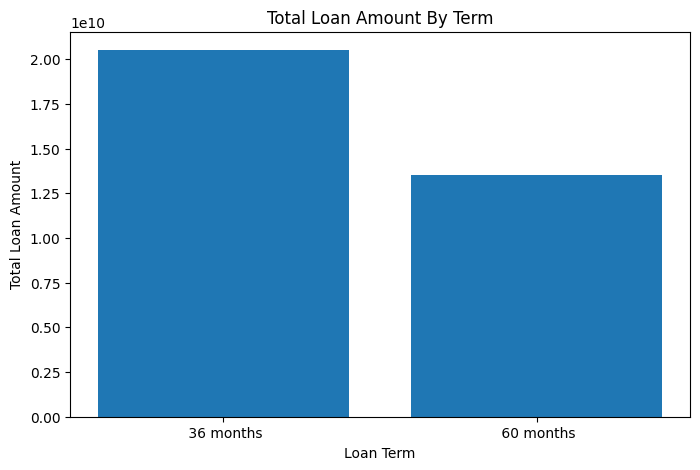

In [75]:
plt.figure(figsize=(8,5))
plt.bar(
    term_to_loan_amnt_dict.keys(),
    term_to_loan_amnt_dict.values())
plt.title("Total Loan Amount By Term")
plt.xlabel("Loan Term")
plt.ylabel("Total Loan Amount")

plt.show()

           

# 문제) 각 대출 상태(불량/우량)에 따른 대출 등급 분포 파악

In [76]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term
0,3600.0,Fully Paid,C,13.99,36 months
1,24700.0,Fully Paid,C,11.99,36 months
2,20000.0,Fully Paid,B,10.78,60 months
3,35000.0,Current,C,14.85,60 months
4,10400.0,Fully Paid,F,22.45,60 months


In [78]:
df2['loan_status'].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [82]:
# loan_status의 unique한 값 뽑기
total_status_category = df2['loan_status'].unique()

# 신용 등급이 안좋은 것만 모으기
bad_status_category = total_status_category[[2,3,4,5,6,8]]

#"Charged Off", "Default", "Does not meet the credit policy.Status:Charged Off", 
#"In Grace Period", "Default Receiver", 
#"Late (16-30 days)", "Late (31-120 days)

bad_status_category

array(['Charged Off', 'In Grace Period', 'Late (31-120 days)',
       'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [85]:
# 열을 추가해서 신용이 좋은지 안좋은지 값 추가(신용 안좋으면 True)
df2['bad_loan_status'] = df2['loan_status'].isin(bad_status_category)
df2.head()

,loan_amnt,loan_status,grade,int_rate,term,bad_loan_status
0,3600.0,Fully Paid,C,13.99,36 months,False
1,24700.0,Fully Paid,C,11.99,36 months,False
2,20000.0,Fully Paid,B,10.78,60 months,False
3,35000.0,Current,C,14.85,60 months,False
4,10400.0,Fully Paid,F,22.45,60 months,False


In [86]:
# 불량신용의 상태인 행의 grade 값에 대한 분포 확인
# 불량신용 상태의 grade 컬럼의 빈도수 계산
bad_loan_status_to_grades = df2.loc[df2['bad_loan_status'] == True, 'grade'].value_counts()
bad_loan_status_to_grades

grade
C    97828
D    68893
B    60213
E    39566
A    16509
F    15594
G     5009
Name: count, dtype: int64

In [87]:
# 등급순 정렬
bad_loan_status_to_grades.sort_index(ascending=True)

grade
A    16509
B    60213
C    97828
D    68893
E    39566
F    15594
G     5009
Name: count, dtype: int64

In [88]:
good_loan_status_to_grades = df2.loc[df2['bad_loan_status'] == False, 'grade'].value_counts()
good_loan_status_to_grades

grade
B    603344
C    552225
A    416518
D    255531
E     96073
F     26206
G      7159
Name: count, dtype: int64

In [89]:
# 신용이 좋은 사람 등급 분포
good_loan_status_to_grades.sort_index()

grade
A    416518
B    603344
C    552225
D    255531
E     96073
F     26206
G      7159
Name: count, dtype: int64

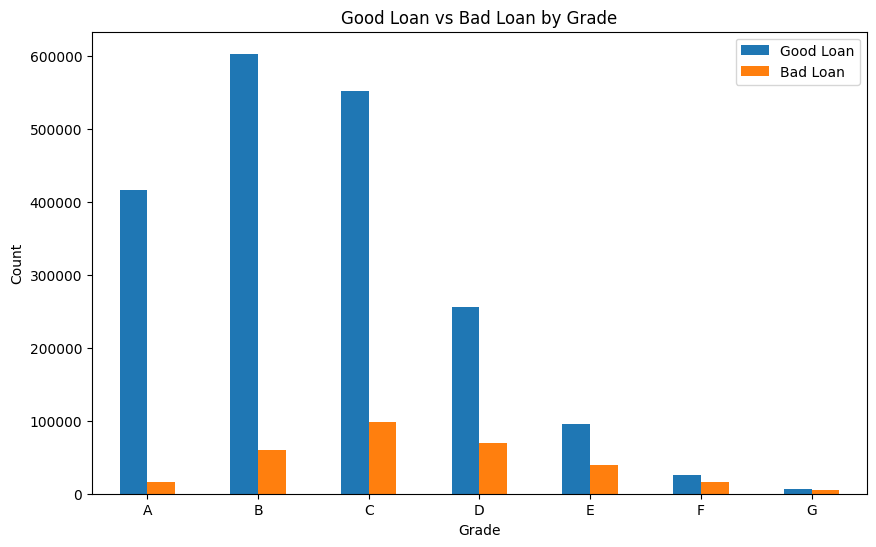

In [90]:
# 우량/불량 등급 분포 정렬
good_grade_counts = good_loan_status_to_grades.sort_index()
bad_grade_counts = bad_loan_status_to_grades.sort_index()

# 두 데이터를 하나의 dataframe으로 결합
compare_df = pd.concat(
    [good_grade_counts, bad_grade_counts],
    axis=1)

# 컬럼명 지정
compare_df.columns = ['Good Loan','Bad Loan']

# 결측값이 있으면 0으로 대체
compare_df = compare_df.fillna(0)

# 시각화
compare_df.plot(kind='bar', figsize=(10,6))

plt.title('Good Loan vs Bad Loan by Grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
    

# 문제) 대출 총액과 대출 이자율 간의 상관관계 파악

In [91]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term,bad_loan_status
0,3600.0,Fully Paid,C,13.99,36 months,False
1,24700.0,Fully Paid,C,11.99,36 months,False
2,20000.0,Fully Paid,B,10.78,60 months,False
3,35000.0,Current,C,14.85,60 months,False
4,10400.0,Fully Paid,F,22.45,60 months,False


In [92]:
df2['loan_amnt'].corr(df2['int_rate'])

np.float64(0.09808178013492737)

In [93]:
grade_status = pd.crosstab(
    df2['grade'],
    df2['bad_loan_status'],
    normalize='index')
grade_status

bad_loan_status,False,True
grade,,
A,0.961875,0.038125
B,0.909257,0.090743
C,0.849508,0.150492
D,0.787645,0.212355
E,0.708299,0.291701
F,0.626938,0.373062
G,0.588346,0.411654


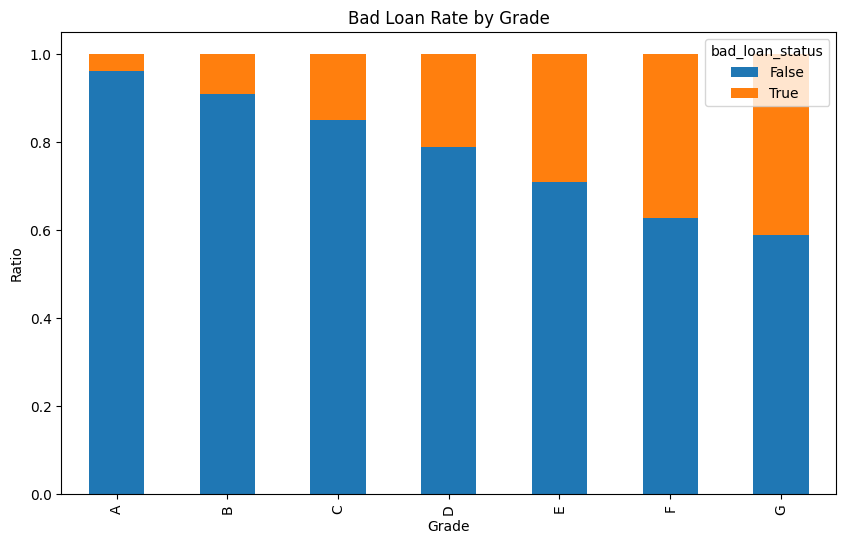

In [95]:
grade_status.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6))

plt.title('Bad Loan Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Ratio')
plt.show()

# 파일쓰기

In [96]:
bad_loan_status_to_grades

grade
C    97828
D    68893
B    60213
E    39566
A    16509
F    15594
G     5009
Name: count, dtype: int64

In [97]:
bad_loan_status_to_grades.sort_index().to_csv('./data/bad_loan_status.csv', sep=',')